# Module 8: Forecasting & Time Series Analysis

This module introduces the fundamentals of time series data-data collected sequentially over time. We will cover techniques for analyzing patterns and forecasting future values.

### Learning Objectives:
- Understand the components of a time series (Trend, Seasonality, Cyclical, Residual).
- Decompose a time series.
- Apply smoothing methods: Moving Averages.
- Apply Exponential Smoothing (Simple and Holt's linear trend).
- Apply Holt-Winters (Triple Exponential Smoothing) for trend and seasonality.
- Understand ARIMA and SARIMA models conceptually and fit them using Python.

In [1]:
# Setup: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# statsmodels has excellent tools for time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
np.random.seed(42)
print("Setup Complete")

Setup Complete


## Section 1: Time Series Fundamentals

Time series data is special because the order matters. We are looking for patterns over time.

### 1.1 Components of a Time Series

1.  **Trend:** The long-term progression of the series (upward, downward, or flat).
2.  **Seasonality:** Repeating patterns or cycles at regular intervals (e.g., daily, monthly, yearly).
3.  **Cyclical:** Patterns that occur at irregular intervals (often related to business cycles).
4.  **Residual (Noise/Irregular):** Unpredictable, random fluctuations.

### 1.2 Generating Time Series Data

Let's create a dataset representing monthly sales over 5 years (60 periods), incorporating trend and seasonality.

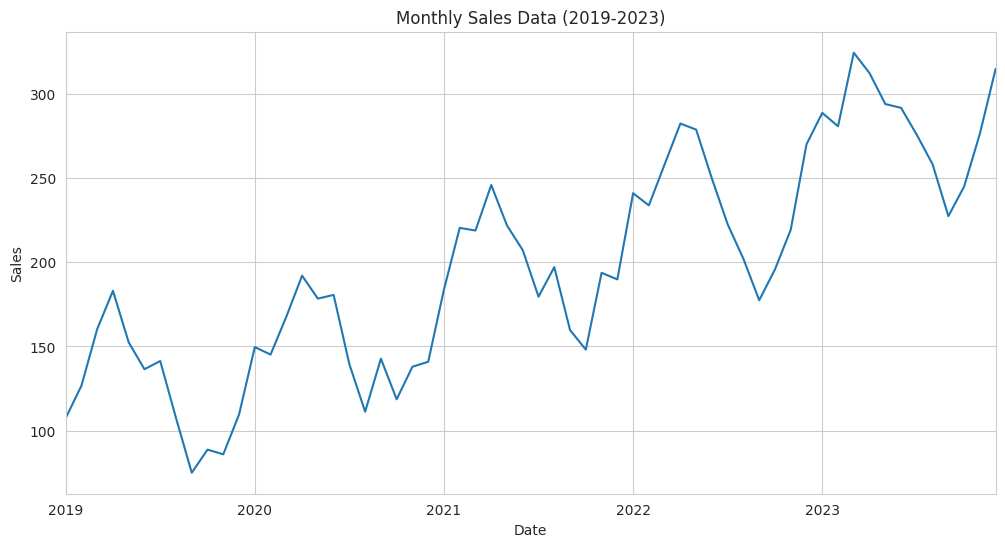

In [2]:
# Create a date range (Monthly frequency)
dates = pd.date_range(start='2019-01-01', periods=60, freq='M')

# Generate components
# Trend: Linear upward trend
trend = np.linspace(100, 300, 60)
# Seasonality: Sinusoidal pattern repeating every 12 months
seasonality = 50 * np.sin(np.linspace(0, 5 * 2 * np.pi, 60))
# Noise
noise = np.random.normal(0, 15, 60)

# Combine components (Additive model: Y = T + S + R)
sales = trend + seasonality + noise

# Create DataFrame
ts_data = pd.DataFrame({'Sales': sales}, index=dates)

# Plot the time series
plt.figure(figsize=(12, 6))
ts_data['Sales'].plot()
plt.title('Monthly Sales Data (2019-2023)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

## Section 2: Time Series Decomposition

We can use statistical methods to separate the time series into its components.

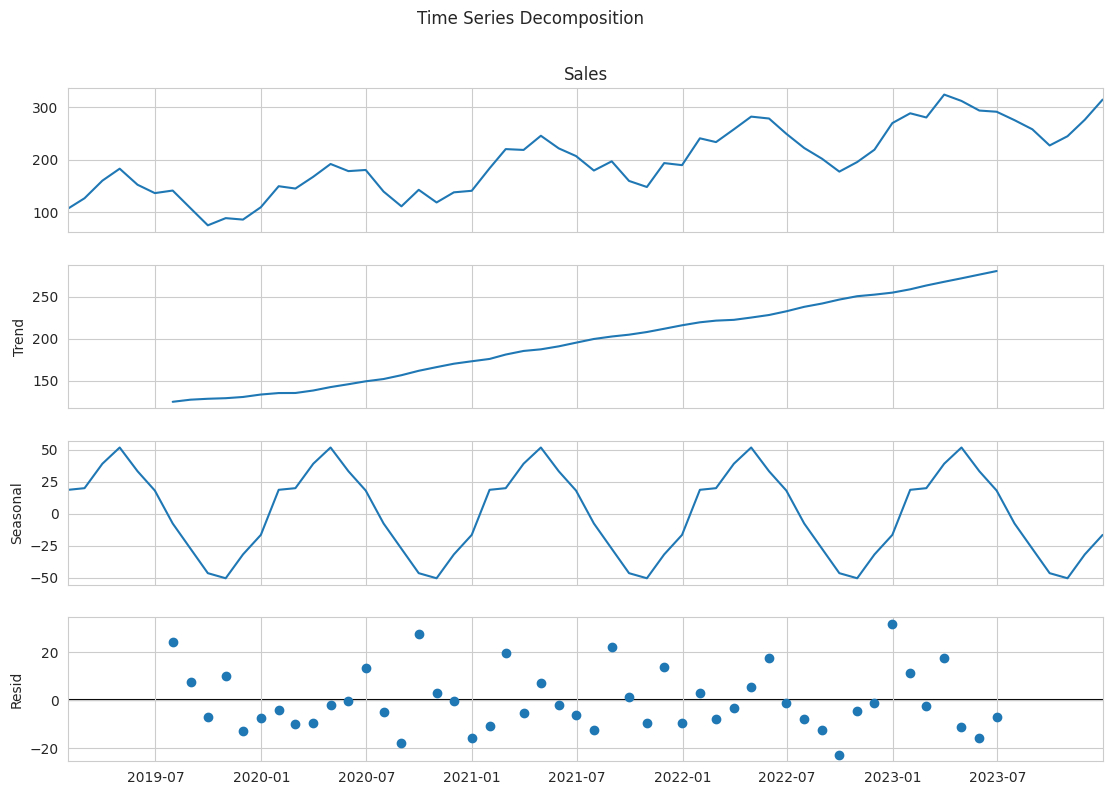

In [3]:
# Perform seasonal decomposition using statsmodels
# We assume an additive model. If the magnitude of seasonality changes with the trend (e.g., higher sales mean larger seasonal swings), use model='multiplicative'.
# period=12 because we have monthly data with yearly seasonality.
decomposition = seasonal_decompose(ts_data['Sales'], model='additive', period=12)

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition', y=1.02)
plt.show()

## Section 3: Smoothing Methods: Moving Averages

Smoothing methods help reduce noise and highlight the underlying trend.

### 3.1 Simple Moving Average (SMA)
The average of a fixed number of past observations. The window 'moves' over time.

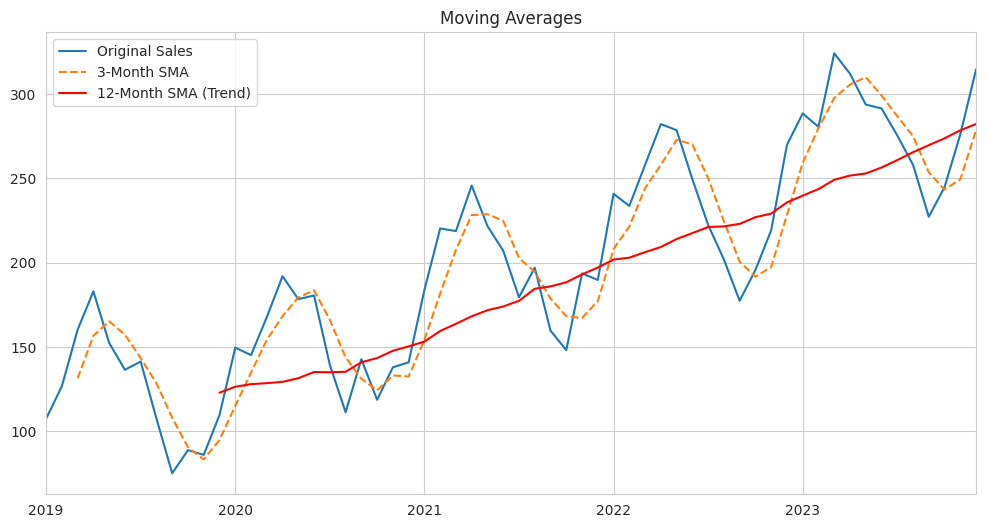

In [4]:
# Calculate Moving Averages
# 3-Month SMA (Short-term smoothing)
ts_data['SMA_3'] = ts_data['Sales'].rolling(window=3).mean()
# 12-Month SMA (Often used to remove yearly seasonality and highlight the trend)
ts_data['SMA_12'] = ts_data['Sales'].rolling(window=12).mean()

# Plotting
plt.figure(figsize=(12, 6))
ts_data['Sales'].plot(label='Original Sales')
ts_data['SMA_3'].plot(label='3-Month SMA', linestyle='--')
ts_data['SMA_12'].plot(label='12-Month SMA (Trend)', color='red')
plt.title('Moving Averages')
plt.legend()
plt.show()

# Note: SMA lags the original data. The 12-month SMA effectively shows the trend without the seasonality.

## Section 4: Exponential Smoothing

Exponential smoothing methods give more weight to recent observations and less weight to older observations, reacting faster to changes than SMA.

### 4.1 Simple Exponential Smoothing (SES)

Suitable for data with no clear trend or seasonality. It uses a smoothing factor (alpha, α).
- High α: Fast learning (more weight to recent data).
- Low α: Slow learning (smoother line).

In [5]:
# Let's demonstrate on a dataset without trend/seasonality.
stable_data = np.random.normal(100, 5, 50)
stable_ts = pd.Series(stable_data)

# Define smoothing factors
alpha_low = 0.2
alpha_high = 0.8

# Apply Simple Exponential Smoothing
model_ses_low = SimpleExpSmoothing(stable_ts).fit(smoothing_level=alpha_low, optimized=False)
model_ses_high = SimpleExpSmoothing(stable_ts).fit(smoothing_level=alpha_high, optimized=False)

# Get the smoothed values (fitted values)
smoothed_low = model_ses_low.fittedvalues
smoothed_high = model_ses_high.fittedvalues

# Plotting
plt.figure(figsize=(12, 6))
stable_ts.plot(label='Original Data')
smoothed_low.plot(label=f'SES (α={alpha_low}) - Smoother', linestyle='--')
smoothed_high.plot(label=f'SES (α={alpha_high}) - More Reactive', linestyle='-.', color='red')
plt.title('Simple Exponential Smoothing')
plt.legend()
plt.show()

### 4.2 Holt's Linear Trend Model (Double Exponential Smoothing)

Extends SES to handle data with a trend. It introduces a second smoothing factor (beta, β) for the trend component.

Let's go back to our original sales data which has a clear trend.

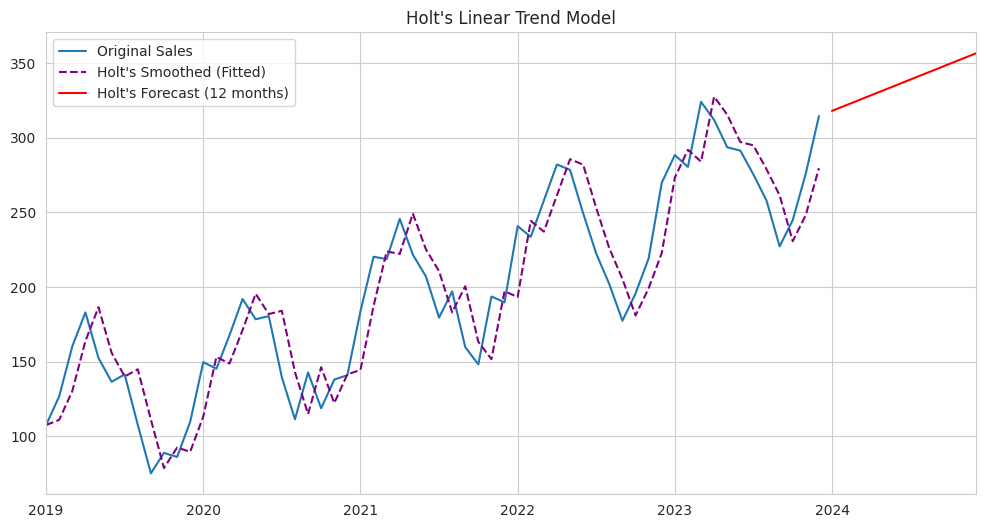

Optimized Alpha (Level): 1.0000
Optimized Beta (Trend): 0.0000


In [6]:
# Apply Holt's model
# We let statsmodels optimize the smoothing levels (alpha and beta) automatically.
model_holt = Holt(ts_data['Sales'], initialization_method='estimated').fit(optimized=True)

# Get the smoothed values
smoothed_holt = model_holt.fittedvalues

# Forecasting the next 12 months
forecast_holt = model_holt.forecast(12)

# Plotting
plt.figure(figsize=(12, 6))
ts_data['Sales'].plot(label='Original Sales')
smoothed_holt.plot(label="Holt's Smoothed (Fitted)", linestyle='--', color='purple')
forecast_holt.plot(label="Holt's Forecast (12 months)", color='red')
plt.title("Holt's Linear Trend Model")
plt.legend()
plt.show()

print(f"Optimized Alpha (Level): {model_holt.params['smoothing_level']:.4f}")
print(f"Optimized Beta (Trend): {model_holt.params['smoothing_trend']:.4f}")

### Observation
Holt's model captures the trend well, but notice the forecast is a straight line. It fails to capture the seasonality present in the data. To handle both trend and seasonality, we need **Holt-Winters (Triple Exponential Smoothing)**, which we explore next.

## Section 5: Holt-Winters (Triple Exponential Smoothing)

Holt-Winters extends Holt's method by adding a **third equation for the seasonal component**. It can handle data with both trend and seasonality.

- **Additive Holt-Winters:** Use when seasonal swings remain constant regardless of the level.
- **Multiplicative Holt-Winters:** Use when seasonal swings grow proportionally with the level.

Three smoothing parameters: $\alpha$ (level), $\beta$ (trend), $\gamma$ (seasonality).

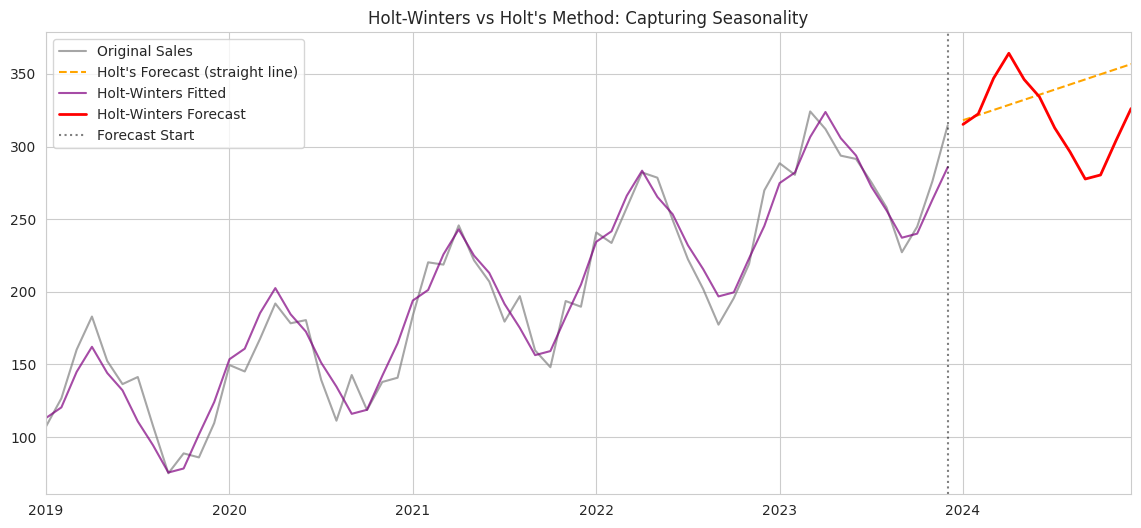

Optimized Alpha (Level):       0.0000
Optimized Beta  (Trend):       0.0000
Optimized Gamma (Seasonality): 0.0000


In [7]:
# Apply Additive Holt-Winters to our sales data (which has trend + seasonality)
model_hw_add = ExponentialSmoothing(
    ts_data['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

# Forecast the next 12 months
forecast_hw_add = model_hw_add.forecast(12)

# Plotting: Compare Holt vs Holt-Winters
plt.figure(figsize=(14, 6))
ts_data['Sales'].plot(label='Original Sales', color='grey', alpha=0.7)
forecast_holt.plot(label="Holt's Forecast (straight line)", color='orange', linestyle='--')
model_hw_add.fittedvalues.plot(label='Holt-Winters Fitted', color='purple', alpha=0.7)
forecast_hw_add.plot(label='Holt-Winters Forecast', color='red', linewidth=2)
plt.axvline(x=ts_data.index[-1], color='black', linestyle=':', alpha=0.5, label='Forecast Start')
plt.title("Holt-Winters vs Holt's Method: Capturing Seasonality")
plt.legend()
plt.show()

print(f"Optimized Alpha (Level):       {model_hw_add.params['smoothing_level']:.4f}")
print(f"Optimized Beta  (Trend):       {model_hw_add.params['smoothing_trend']:.4f}")
print(f"Optimized Gamma (Seasonality): {model_hw_add.params['smoothing_seasonal']:.4f}")

### Observation
Notice how Holt-Winters captures **both** the upward trend and the seasonal oscillations. The forecast (red line) continues the seasonal pattern forward, unlike Holt's straight-line forecast. This makes Holt-Winters the most practical smoothing method for real-world business data.

## Section 6: Beyond Smoothing - ARIMA & SARIMA

Smoothing methods are intuitive and practical, but they are primarily descriptive tools. **ARIMA** (AutoRegressive Integrated Moving Average) provides a more rigorous statistical framework built around the idea that a value can be expressed as a **linear function of its own past values and past forecast errors**.

- **AR(p):** Value depends on its own $p$ past values (autoregressive)
- **I(d):** Differencing $d$ times to remove trends (making it stationary)
- **MA(q):** Value depends on past $q$ forecast errors (not the same as Moving Average smoothing!)

**SARIMA** extends ARIMA by adding seasonal parameters: $SARIMA(p,d,q)(P,D,Q)_m$

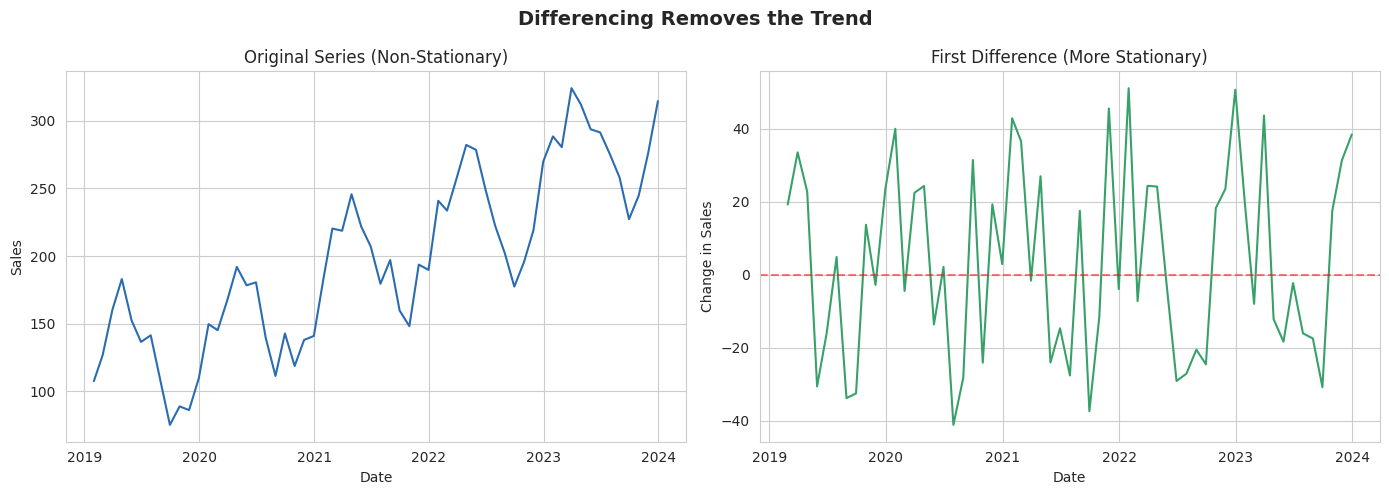

Original mean changes over time (non-stationary).
After differencing, the series fluctuates around zero (closer to stationary).


In [8]:
# 6.1 Visualising Stationarity: Original vs Differenced Data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data (non-stationary: has trend)
axes[0].plot(ts_data['Sales'], color='#2b6cb0')
axes[0].set_title('Original Series (Non-Stationary)')
axes[0].set_ylabel('Sales')
axes[0].set_xlabel('Date')

# First difference (removes linear trend, closer to stationary)
diff_sales = ts_data['Sales'].diff().dropna()
axes[1].plot(diff_sales, color='#38a169')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('First Difference (More Stationary)')
axes[1].set_ylabel('Change in Sales')
axes[1].set_xlabel('Date')

plt.suptitle('Differencing Removes the Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Original mean changes over time (non-stationary).")
print("After differencing, the series fluctuates around zero (closer to stationary).")

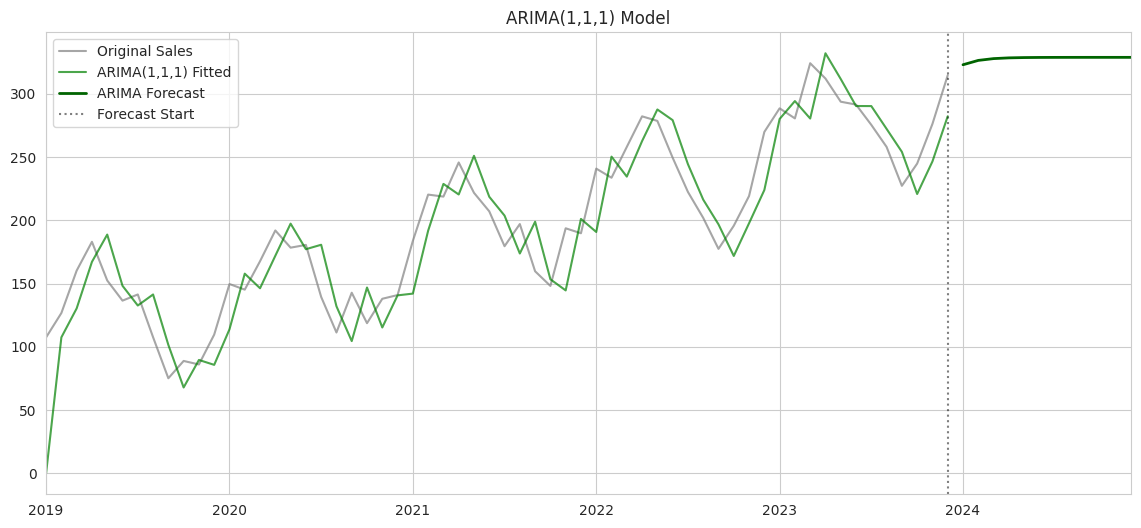

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4120      0.623      0.662      0.508      -0.808       1.632
ma.L1         -0.2313      0.668     -0.346      0.729      -1.541       1.079
sigma2       651.1798    183.011      3.558      0.000     292.485    1009.875


In [9]:
# 6.2 Fitting an ARIMA Model
# ARIMA(1, 1, 1): AR(1) + one differencing + MA(1)
model_arima = ARIMA(ts_data['Sales'], order=(1, 1, 1)).fit()

# Forecast 12 months ahead
forecast_arima = model_arima.forecast(12)

# Plotting
plt.figure(figsize=(14, 6))
ts_data['Sales'].plot(label='Original Sales', color='grey', alpha=0.7)
model_arima.fittedvalues.plot(label='ARIMA(1,1,1) Fitted', color='green', alpha=0.7)
forecast_arima.plot(label='ARIMA Forecast', color='darkgreen', linewidth=2)
plt.axvline(x=ts_data.index[-1], color='black', linestyle=':', alpha=0.5, label='Forecast Start')
plt.title('ARIMA(1,1,1) Model')
plt.legend()
plt.show()

print(model_arima.summary().tables[1])

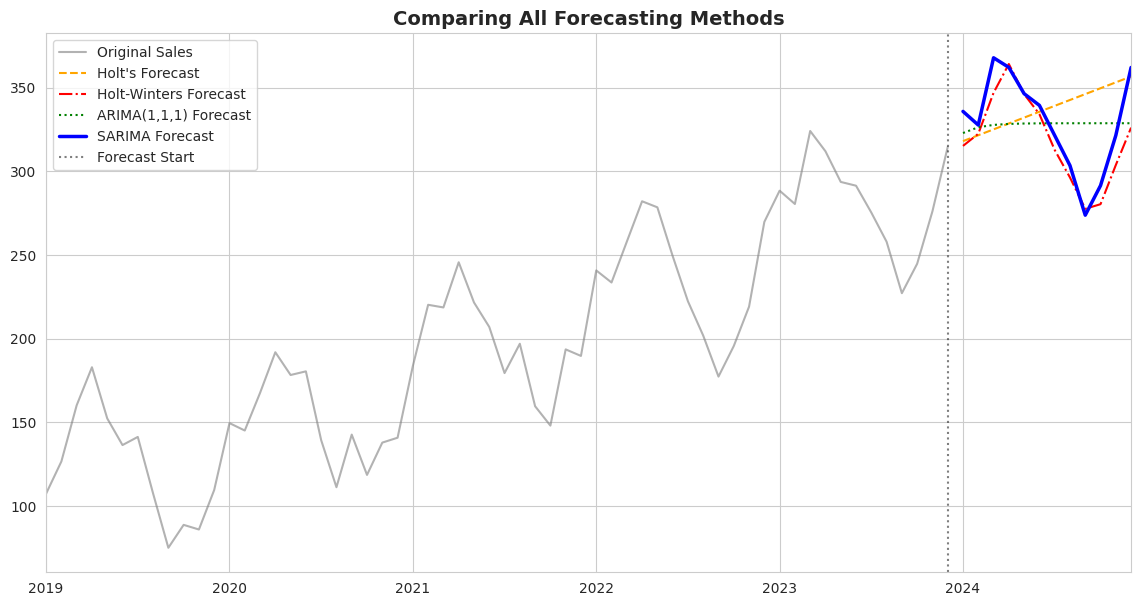

Notice how SARIMA and Holt-Winters both capture seasonality in the forecast,
while Holt and ARIMA(1,1,1) produce straight-line forecasts.


In [10]:
# 6.3 Fitting a SARIMA Model
# SARIMA(1,1,1)(1,1,1,12): adds seasonal AR, differencing, and MA with period 12
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    ts_data['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast 12 months ahead
forecast_sarima = model_sarima.forecast(12)

# Plotting: Compare all forecasting methods
plt.figure(figsize=(14, 7))
ts_data['Sales'].plot(label='Original Sales', color='grey', alpha=0.6)
forecast_holt.plot(label="Holt's Forecast", color='orange', linestyle='--', linewidth=1.5)
forecast_hw_add.plot(label='Holt-Winters Forecast', color='red', linestyle='-.', linewidth=1.5)
forecast_arima.plot(label='ARIMA(1,1,1) Forecast', color='green', linestyle=':', linewidth=1.5)
forecast_sarima.plot(label='SARIMA Forecast', color='blue', linewidth=2.5)
plt.axvline(x=ts_data.index[-1], color='black', linestyle=':', alpha=0.5, label='Forecast Start')
plt.title('Comparing All Forecasting Methods', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.show()

print("Notice how SARIMA and Holt-Winters both capture seasonality in the forecast,")
print("while Holt and ARIMA(1,1,1) produce straight-line forecasts.")

## Summary: Choosing the Right Method

| Data Characteristics | Recommended Method | Parameters |
|---|---|---|
| No trend, no seasonality | Simple Exponential Smoothing | $\alpha$ |
| Trend only | Holt's Linear Trend | $\alpha, \beta$ |
| Trend + constant seasonality | Additive Holt-Winters | $\alpha, \beta, \gamma$ |
| Trend + proportional seasonality | Multiplicative Holt-Winters | $\alpha, \beta, \gamma$ |
| Formal statistical modelling | ARIMA / SARIMA | $(p, d, q)$ / $(P, D, Q)_m$ |

**Key takeaway:** Start by plotting your data. The shape of the time series tells you which method to use. Smoothing methods are intuitive and practical. ARIMA/SARIMA provide a rigorous statistical framework with hypothesis testing and confidence intervals.